Xavier Plantier

# Text Flappy Bird - Reinforcement Learning Assignment

This notebook implements and compares two RL agents on the `TextFlappyBird-v0` environment:
1. **Monte Carlo Control** (on-policy, first-visit, ε-greedy)
2. **Sarsa(λ)** with accumulating traces (Sutton & Barto, Section 12.7)

The observation used is the `(dx, dy)` distance from the player to the center of the next pipe gap.

## 1. Setup and Installation

In [25]:
import torch
import tensorflow as tf

# Vérification avec PyTorch
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'PyTorch utilise le GPU : {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('PyTorch utilise le CPU')

# Vérification avec TensorFlow
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f'TensorFlow a trouvé {len(gpu_devices)} GPU(s)')
else:
    print('TensorFlow utilise le CPU')

PyTorch utilise le GPU : Tesla T4
TensorFlow a trouvé 1 GPU(s)


In [1]:
# Install the Text Flappy Bird environment
!pip install git+https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git
!pip install gymnasium numpy matplotlib tqdm

  Cloning https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git to /tmp/pip-req-build-481670ru
  Running command git clone --filter=blob:none --quiet https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git /tmp/pip-req-build-481670ru
  Resolved https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git to commit ca2797e9270195313423324c9d0f205f6cbb3d28
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 23.3 MB/s eta 0:00:00
  Created wheel for text-flappy-bird-gym: filename=text_flappy_bird_gym-0.1.1-py3-none-any.whl size=7771 sha256=50c6368d29e6419d38ea9137ce3eb5acee03cf6ca7b76c63ac1e293961be64ad
  Stored in directory: /tmp/pip-ephem-wheel-cache-kfgcak0l/wheels/35/9c/d0/221915af4a2a308c87c31a94dab358d6a7c71c1cebb5d36e7b
Successfully built text-flappy-bird-gym
  Attempting uninstall: gymnasium
    Found existing installation: gym

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import text_flappy_bird_gym
from collections import defaultdict
from tqdm import tqdm
import pickle
import time

np.random.seed(42)

# Create environment
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
obs, info = env.reset()
print('Observation:', obs)
print('Action space:', env.action_space)
print('Observation space:', env.observation_space)

Observation: (13, -2)
Action space: Discrete(2)
Observation space: Tuple(Discrete(14), Discrete(22, start=-11))


## 2. Monte Carlo Control Agent (On-policy, First-visit, ε-greedy)

We estimate $Q(s,a)$ by averaging returns from first visits in each episode, and improve the policy with ε-greedy. The state is the discrete tuple `(dx, dy)` returned by the environment.

In [3]:
class MonteCarloAgent:
    """On-policy first-visit MC control with epsilon-greedy policy."""

    def __init__(self, n_actions=2, gamma=1.0, epsilon=0.1, epsilon_decay=0.9999, epsilon_min=0.01):
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.Q = defaultdict(lambda: np.zeros(n_actions))
        self.returns_count = defaultdict(lambda: np.zeros(n_actions))

    def policy(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def greedy_action(self, state):
        return int(np.argmax(self.Q[state]))

    def generate_episode(self, env, max_steps=10000):
        episode = []
        state, _ = env.reset()
        for _ in range(max_steps):
            action = self.policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            if terminated or truncated:
                break
        return episode

    def update(self, episode):
        G = 0.0
        visited = set()
        # First-visit MC: walk backwards
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = self.gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                self.returns_count[state][action] += 1
                # Incremental mean update
                n = self.returns_count[state][action]
                self.Q[state][action] += (G - self.Q[state][action]) / n

    def train(self, env, n_episodes=20000):
        rewards_history = []
        for ep in tqdm(range(n_episodes), desc='MC training'):
            episode = self.generate_episode(env)
            self.update(episode)
            total_reward = sum(r for _, _, r in episode)
            rewards_history.append(total_reward)
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        return rewards_history

In [4]:
mc_agent = MonteCarloAgent(n_actions=2, gamma=1.0, epsilon=0.1, epsilon_decay=0.9999)
mc_rewards = mc_agent.train(env, n_episodes=20000)
print(f'MC: final epsilon = {mc_agent.epsilon:.4f}, states learned = {len(mc_agent.Q)}')

MC training: 100%|██████████| 20000/20000 [00:31<00:00, 642.02it/s]

MC: final epsilon = 0.0135, states learned = 272


## 3. Sarsa(λ) Agent with Accumulating Traces

Following Sutton & Barto, Section 12.7. Update rule:
- $\delta_t = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)$
- $e(S_t, A_t) \leftarrow e(S_t, A_t) + 1$ (accumulating)
- $Q(s,a) \leftarrow Q(s,a) + \alpha \delta_t e(s,a)$
- $e(s,a) \leftarrow \gamma \lambda e(s,a)$

In [5]:
class SarsaLambdaAgent:
    """Tabular Sarsa(lambda) with accumulating eligibility traces."""

    def __init__(self, n_actions=2, alpha=0.1, gamma=1.0, lam=0.9,
                 epsilon=0.1, epsilon_decay=0.9999, epsilon_min=0.01):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lam = lam
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.Q = defaultdict(lambda: np.zeros(n_actions))

    def policy(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def greedy_action(self, state):
        return int(np.argmax(self.Q[state]))

    def train(self, env, n_episodes=20000, max_steps=10000):
        rewards_history = []
        for ep in tqdm(range(n_episodes), desc='Sarsa(lambda) training'):
            E = defaultdict(lambda: np.zeros(self.n_actions))
            state, _ = env.reset()
            action = self.policy(state)
            total_reward = 0.0
            for _ in range(max_steps):
                next_state, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated
                if done:
                    delta = reward - self.Q[state][action]
                else:
                    next_action = self.policy(next_state)
                    delta = reward + self.gamma * self.Q[next_state][next_action] - self.Q[state][action]
                E[state][action] += 1.0  # accumulating trace
                # Update all visited (s,a)
                for s, vec in list(E.items()):
                    self.Q[s] += self.alpha * delta * vec
                    E[s] = self.gamma * self.lam * vec
                if done:
                    break
                state, action = next_state, next_action
            rewards_history.append(total_reward)
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        return rewards_history

In [6]:
sarsa_agent = SarsaLambdaAgent(n_actions=2, alpha=0.1, gamma=1.0, lam=0.9, epsilon=0.1)
sarsa_rewards = sarsa_agent.train(env, n_episodes=20000)
print(f'Sarsa(lambda): final epsilon = {sarsa_agent.epsilon:.4f}, states learned = {len(sarsa_agent.Q)}')

Sarsa(lambda) training: 100%|██████████| 20000/20000 [24:38<00:00, 13.53it/s]

Sarsa(lambda): final epsilon = 0.0135, states learned = 271


In [26]:
print(f"MC final (last 500): {np.mean(mc_rewards[-500:]):.1f}")
print(f"MC max: {max(mc_rewards):.0f}")
print(f"MC states: {len(mc_agent.Q)}")
print(f"Sarsa final (last 500): {np.mean(sarsa_rewards[-500:]):.1f}")
print(f"Sarsa max: {max(sarsa_rewards):.0f}")
print(f"Sarsa states: {len(sarsa_agent.Q)}")

MC final (last 500): 186.6
MC max: 2403
MC states: 272
Sarsa final (last 500): 643.1
Sarsa max: 5503
Sarsa states: 271


## 4. Learning Curves Comparison

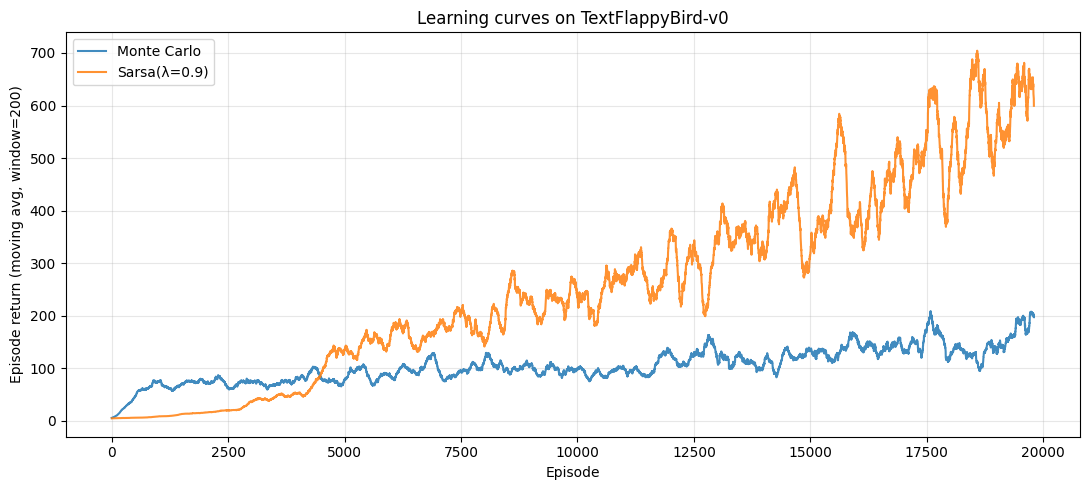

In [7]:
def moving_average(x, w=200):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(11, 5))
plt.plot(moving_average(mc_rewards), label='Monte Carlo', alpha=0.85)
plt.plot(moving_average(sarsa_rewards), label='Sarsa(λ=0.9)', alpha=0.85)
plt.xlabel('Episode')
plt.ylabel('Episode return (moving avg, window=200)')
plt.title('Learning curves on TextFlappyBird-v0')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Greedy Policy Evaluation

In [8]:
def evaluate_greedy(agent, env, n_episodes=100, max_steps=10000):
    returns = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        total = 0.0
        for _ in range(max_steps):
            action = agent.greedy_action(state)
            state, r, term, trunc, _ = env.step(action)
            total += r
            if term or trunc:
                break
        returns.append(total)
    return np.mean(returns), np.std(returns), np.max(returns)

mc_mean, mc_std, mc_max = evaluate_greedy(mc_agent, env, 100)
sa_mean, sa_std, sa_max = evaluate_greedy(sarsa_agent, env, 100)

print(f'MC          -> mean={mc_mean:.1f} std={mc_std:.1f} max={mc_max:.0f}')
print(f'Sarsa(λ)    -> mean={sa_mean:.1f} std={sa_std:.1f} max={sa_max:.0f}')

MC          -> mean=357.3 std=286.6 max=1596
Sarsa(λ)    -> mean=1010.0 std=872.1 max=3593


## 6. State-Value Function Visualization

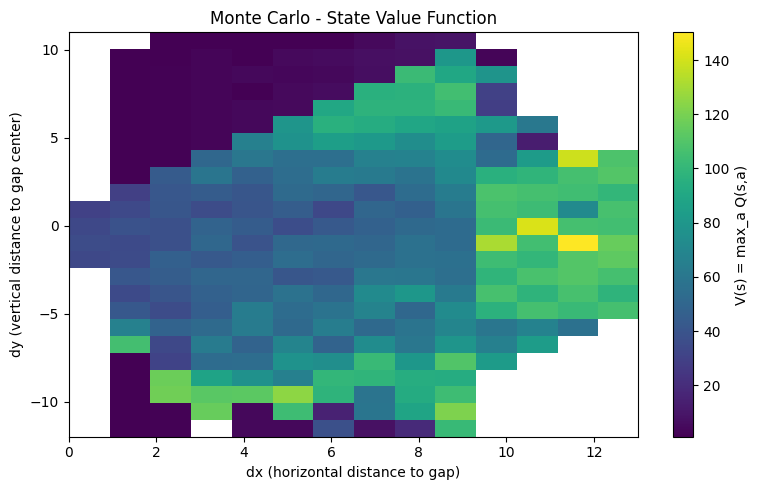

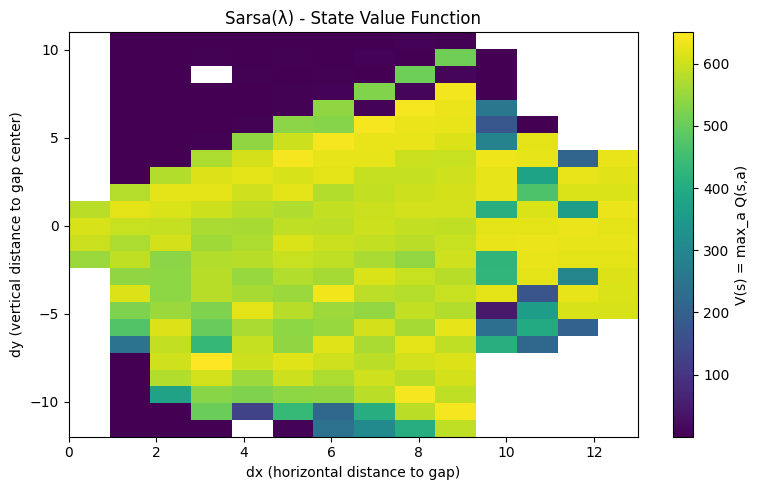

In [9]:
def plot_value_function(agent, title):
    if len(agent.Q) == 0:
        print('Empty Q-table')
        return
    states = list(agent.Q.keys())
    dxs = [s[0] for s in states]
    dys = [s[1] for s in states]
    dx_min, dx_max = min(dxs), max(dxs)
    dy_min, dy_max = min(dys), max(dys)
    V = np.full((dy_max - dy_min + 1, dx_max - dx_min + 1), np.nan)
    for (dx, dy), q in agent.Q.items():
        V[dy - dy_min, dx - dx_min] = np.max(q)
    plt.figure(figsize=(8, 5))
    im = plt.imshow(V, origin='lower', aspect='auto',
                    extent=[dx_min, dx_max, dy_min, dy_max], cmap='viridis')
    plt.colorbar(im, label='V(s) = max_a Q(s,a)')
    plt.xlabel('dx (horizontal distance to gap)')
    plt.ylabel('dy (vertical distance to gap center)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_value_function(mc_agent, 'Monte Carlo - State Value Function')
plot_value_function(sarsa_agent, 'Sarsa(λ) - State Value Function')

## Q1: Parameter sensitivity analysis

Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:03<00:00, 1386.31it/s]


lambda=0.0: last-500 avg return = 11.2


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:01<00:00, 2606.53it/s]


lambda=0.3: last-500 avg return = 11.1


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:01<00:00, 3102.57it/s]


lambda=0.6: last-500 avg return = 11.2


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:23<00:00, 215.89it/s]


lambda=0.9: last-500 avg return = 111.1


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:05<00:00, 894.41it/s]


lambda=0.99: last-500 avg return = 33.5


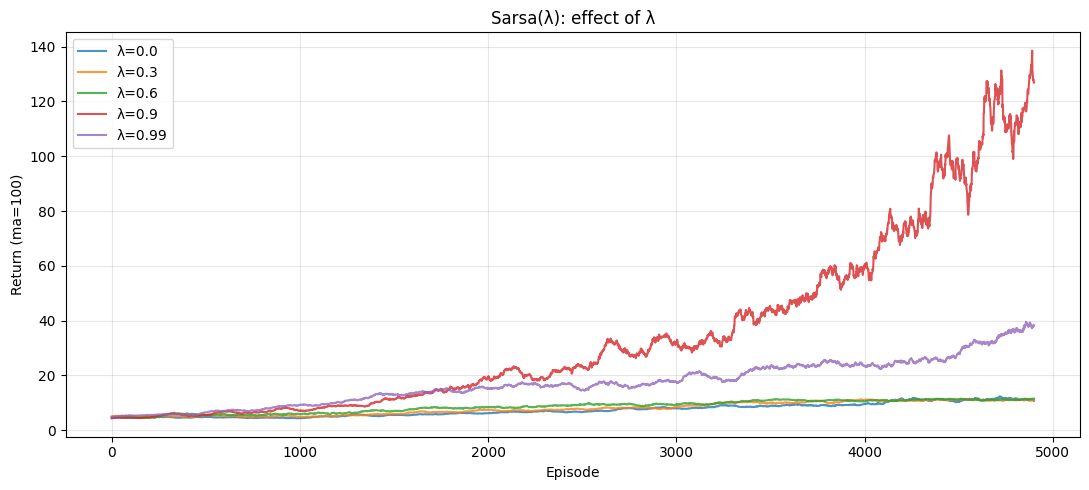

In [10]:
lambdas = [0.0, 0.3, 0.6, 0.9, 0.99]
sweep_results = {}
for lam in lambdas:
    agent = SarsaLambdaAgent(n_actions=2, alpha=0.1, gamma=1.0, lam=lam, epsilon=0.1)
    rewards = agent.train(env, n_episodes=5000)
    sweep_results[lam] = rewards
    print(f'lambda={lam}: last-500 avg return = {np.mean(rewards[-500:]):.1f}')

plt.figure(figsize=(11, 5))
for lam, r in sweep_results.items():
    plt.plot(moving_average(r, 100), label=f'λ={lam}', alpha=0.8)
plt.xlabel('Episode'); plt.ylabel('Return (ma=100)')
plt.title('Sarsa(λ): effect of λ')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:01<00:00, 4953.41it/s]


alpha=0.01: last-500 avg = 5.9


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:02<00:00, 1995.62it/s]


alpha=0.05: last-500 avg = 13.9


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:03<00:00, 1401.03it/s]


alpha=0.1: last-500 avg = 23.3


Sarsa(lambda) training: 100%|██████████| 5000/5000 [01:21<00:00, 61.42it/s]


alpha=0.2: last-500 avg = 114.1


Sarsa(lambda) training: 100%|██████████| 5000/5000 [01:14<00:00, 67.16it/s]


alpha=0.5: last-500 avg = 105.0


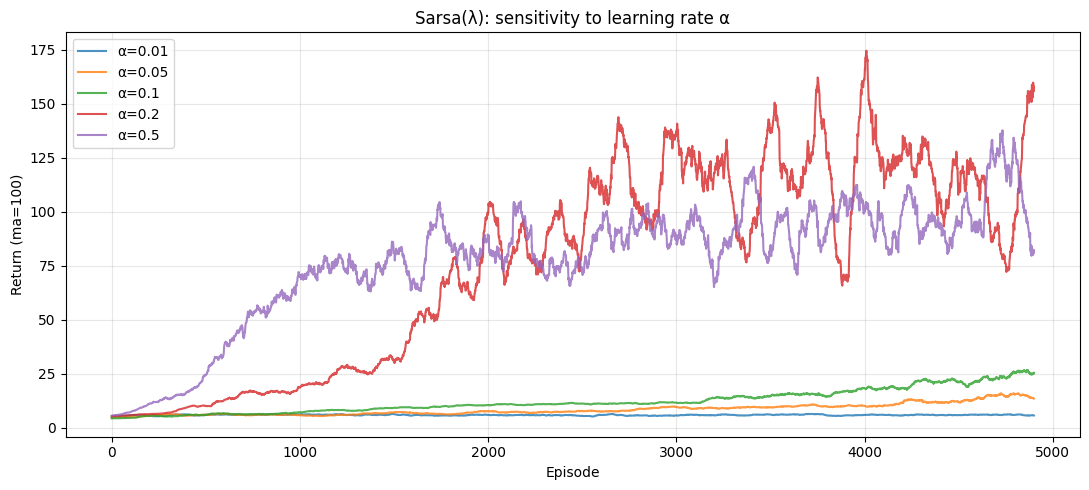

In [12]:
# Sweep over alpha for Sarsa(lambda)
alphas = [0.01, 0.05, 0.1, 0.2, 0.5]
alpha_results = {}
for a in alphas:
    agent = SarsaLambdaAgent(n_actions=2, alpha=a, gamma=1.0, lam=0.9, epsilon=0.1)
    rewards = agent.train(env, n_episodes=5000)
    alpha_results[a] = rewards
    print(f'alpha={a}: last-500 avg = {np.mean(rewards[-500:]):.1f}')

plt.figure(figsize=(11, 5))
for a, r in alpha_results.items():
    plt.plot(moving_average(r, 100), label=f'α={a}', alpha=0.8)
plt.xlabel('Episode'); plt.ylabel('Return (ma=100)')
plt.title('Sarsa(λ): sensitivity to learning rate α')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:07<00:00, 643.10it/s]


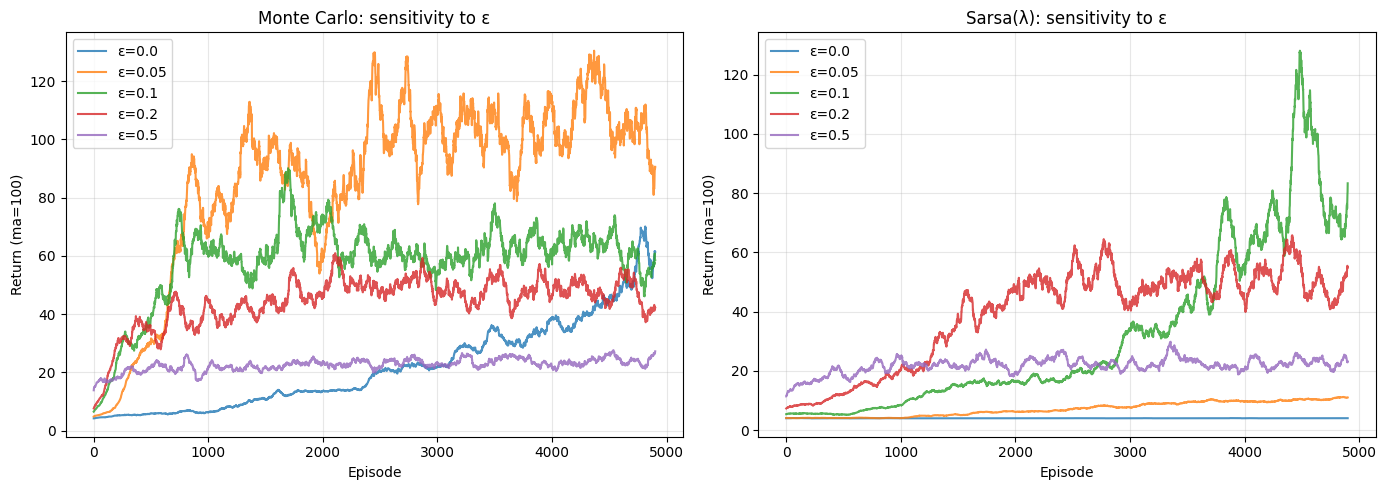

In [13]:
# Sweep over epsilon for both agents
epsilons = [0.0, 0.05, 0.1, 0.2, 0.5]
mc_eps_results = {}
sa_eps_results = {}
for e in epsilons:
    mc = MonteCarloAgent(n_actions=2, gamma=1.0, epsilon=e, epsilon_decay=1.0)
    mc_eps_results[e] = mc.train(env, n_episodes=5000)
    sa = SarsaLambdaAgent(n_actions=2, alpha=0.1, gamma=1.0, lam=0.9, epsilon=e, epsilon_decay=1.0)
    sa_eps_results[e] = sa.train(env, n_episodes=5000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for e, r in mc_eps_results.items():
    axes[0].plot(moving_average(r, 100), label=f'ε={e}', alpha=0.8)
axes[0].set_title('Monte Carlo: sensitivity to ε')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return (ma=100)')
axes[0].legend(); axes[0].grid(alpha=0.3)

for e, r in sa_eps_results.items():
    axes[1].plot(moving_average(r, 100), label=f'ε={e}', alpha=0.8)
axes[1].set_title('Sarsa(λ): sensitivity to ε')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Return (ma=100)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [14]:
# Convergence time and final performance comparison table
def convergence_episode(rewards, threshold_ratio=0.9, window=200):
    """Episode at which moving average first reaches threshold_ratio * max."""
    ma = moving_average(rewards, window)
    if len(ma) == 0:
        return None
    target = threshold_ratio * np.max(ma)
    above = np.where(ma >= target)[0]
    return int(above[0]) if len(above) > 0 else None

print(f"{'Agent':<20}{'Final return':<18}{'Max return':<15}{'Conv. episode':<15}{'#States':<10}")
print('-' * 78)
mc_final = np.mean(mc_rewards[-500:])
sa_final = np.mean(sarsa_rewards[-500:])
print(f"{'Monte Carlo':<20}{mc_final:<18.1f}{max(mc_rewards):<15.0f}{str(convergence_episode(mc_rewards)):<15}{len(mc_agent.Q):<10}")
print(f"{'Sarsa(λ=0.9)':<20}{sa_final:<18.1f}{max(sarsa_rewards):<15.0f}{str(convergence_episode(sarsa_rewards)):<15}{len(sarsa_agent.Q):<10}")

Agent               Final return      Max return     Conv. episode  #States   
------------------------------------------------------------------------------
Monte Carlo         186.6             2403           17526          272       
Sarsa(λ=0.9)        643.1             5503           17648          271       


## Q2: TextFlappyBird-v0 vs TextFlappyBird-screen-v0


In [15]:
env_v0 = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
env_screen = gym.make('TextFlappyBird-screen-v0', height=15, width=20, pipe_gap=4)

obs_v0, _ = env_v0.reset()
obs_screen, _ = env_screen.reset()

print('--- TextFlappyBird-v0 ---')
print('Observation type:', type(obs_v0))
print('Observation:', obs_v0)
print('Observation space:', env_v0.observation_space)
print()
print('--- TextFlappyBird-screen-v0 ---')
print('Observation type:', type(obs_screen))
print('Observation shape:', np.array(obs_screen).shape)
print('Observation space:', env_screen.observation_space)

# Estimate state-space size
print()
print('Approx. state space sizes:')
print(f'  v0 (dx, dy): ~{20*15} = 300 discrete states')
print(f'  screen-v0:    2^({15*20}) ≈ {2**(15*20):.2e} possible binary screens')

env_v0.close(); env_screen.close()

--- TextFlappyBird-v0 ---
Observation type: <class 'tuple'>
Observation: (13, 1)
Observation space: Tuple(Discrete(14), Discrete(22, start=-11))

--- TextFlappyBird-screen-v0 ---
Observation type: <class 'numpy.ndarray'>
Observation shape: (20, 15)
Observation space: Box(0, 3, (20, 15), int32)

Approx. state space sizes:
  v0 (dx, dy): ~300 = 300 discrete states
  screen-v0:    2^(300) ≈ 2.04e+90 possible binary screens


## Q3: Same agents be used on the original flappy-bird-gym

In [16]:

# Original game: pip install flappy-bird-gym
# import flappy_bird_gym
# env_orig = flappy_bird_gym.make("FlappyBird-v0")
# obs, _ = env_orig.reset()
# print('Original FlappyBird obs:', obs, 'shape:', np.array(obs).shape)
#
# The original env returns continuous (horizontal_distance, vertical_distance) floats.
# A naive tabular agent would NOT work directly because:
#   - state space is continuous → infinite states
#   - dict-based Q-table cannot generalize between nearby states
# Solutions:
#   (a) Discretize the observation (binning) and reuse the same agents
#   (b) Use function approximation (tile coding, neural networks)

def discretize(obs, bins=(20, 20), low=(-1.0, -1.0), high=(1.0, 1.0)):
    """Map a continuous 2D obs to a discrete tuple."""
    out = []
    for i, x in enumerate(obs):
        x = np.clip(x, low[i], high[i])
        idx = int((x - low[i]) / (high[i] - low[i]) * (bins[i] - 1))
        out.append(idx)
    return tuple(out)

# Wrapper class that allows reusing MonteCarloAgent / SarsaLambdaAgent
class DiscretizedEnv:
    def __init__(self, env, bins=(20, 20), low=(-1.0, -1.0), high=(1.0, 1.0)):
        self.env = env
        self.bins, self.low, self.high = bins, low, high
        self.action_space = env.action_space
    def reset(self):
        obs, info = self.env.reset()
        return discretize(obs, self.bins, self.low, self.high), info
    def step(self, a):
        obs, r, term, trunc, info = self.env.step(a)
        return discretize(obs, self.bins, self.low, self.high), r, term, trunc, info
    def close(self):
        self.env.close()

print('Discretization wrapper defined — both agents can be reused on the original game.')

Discretization wrapper defined — both agents can be reused on the original game.


## Q4: Trained agent transferred to a different TFB configuration

In [17]:
configs = [
    {'height': 15, 'width': 20, 'pipe_gap': 4},   # training config
    {'height': 15, 'width': 20, 'pipe_gap': 3},   # harder gap
    {'height': 15, 'width': 20, 'pipe_gap': 5},   # easier gap
    {'height': 20, 'width': 25, 'pipe_gap': 4},   # bigger world
    {'height': 10, 'width': 15, 'pipe_gap': 4},   # smaller world
    {'height': 15, 'width': 20, 'pipe_gap': 6},   # very easy
]

def evaluate_on_config(agent, cfg, n_episodes=50, max_steps=2000):
    e = gym.make('TextFlappyBird-v0', **cfg)
    returns = []
    for _ in range(n_episodes):
        s, _ = e.reset()
        total = 0.0
        for _ in range(max_steps):
            # Unknown states → fallback to action 0 (no flap)
            a = int(np.argmax(agent.Q[s])) if s in agent.Q else 0
            s, r, term, trunc, _ = e.step(a)
            total += r
            if term or trunc:
                break
        returns.append(total)
    e.close()
    return np.mean(returns), np.std(returns)

print(f"{'Config':<40}{'MC mean±std':<22}{'Sarsa mean±std':<22}")
print('-' * 84)
results_transfer = []
for cfg in configs:
    mc_m, mc_s = evaluate_on_config(mc_agent, cfg, n_episodes=30)
    sa_m, sa_s = evaluate_on_config(sarsa_agent, cfg, n_episodes=30)
    results_transfer.append((cfg, mc_m, mc_s, sa_m, sa_s))
    label = f"h={cfg['height']} w={cfg['width']} gap={cfg['pipe_gap']}"
    print(f"{label:<40}{mc_m:>7.1f} ± {mc_s:<10.1f}{sa_m:>7.1f} ± {sa_s:<10.1f}")

Config                                  MC mean±std           Sarsa mean±std        
------------------------------------------------------------------------------------
h=15 w=20 gap=4                           330.9 ± 322.6      1075.5 ± 663.3     
h=15 w=20 gap=3                            43.2 ± 39.5         14.0 ± 3.0       
h=15 w=20 gap=5                           437.3 ± 394.3      1431.2 ± 663.9     
h=20 w=25 gap=4                             4.0 ± 0.0           4.0 ± 0.0       
h=10 w=15 gap=4                           134.0 ± 143.7       443.3 ± 432.2     
h=15 w=20 gap=6                           348.5 ± 316.8      1873.0 ± 475.3     


## Q5: Comprehensive results summary

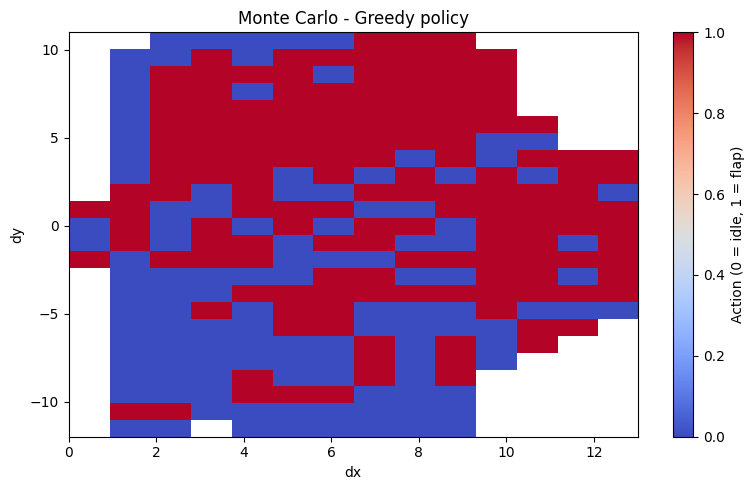

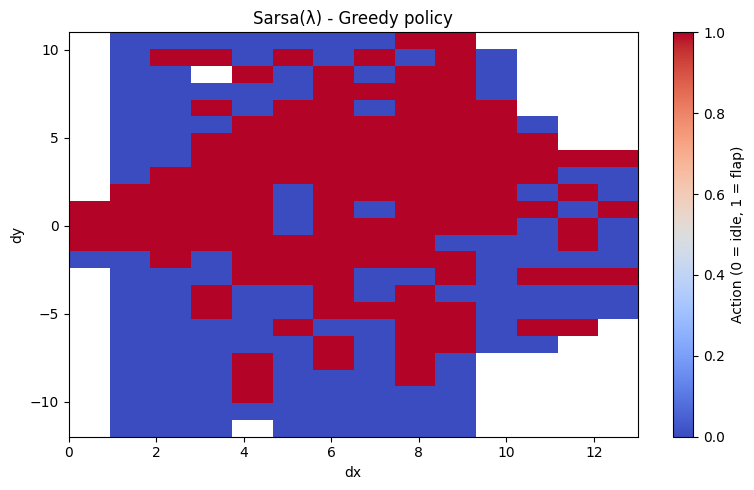

In [20]:

# Greedy policy heatmap (action chosen at each state)
def plot_policy(agent, title):
    if not agent.Q: return
    states = list(agent.Q.keys())
    dxs, dys = [s[0] for s in states], [s[1] for s in states]
    dx_min, dx_max, dy_min, dy_max = min(dxs), max(dxs), min(dys), max(dys)
    P = np.full((dy_max - dy_min + 1, dx_max - dx_min + 1), np.nan)
    for (dx, dy), q in agent.Q.items():
        P[dy - dy_min, dx - dx_min] = np.argmax(q)
    plt.figure(figsize=(8, 5))
    plt.imshow(P, origin='lower', aspect='auto',
               extent=[dx_min, dx_max, dy_min, dy_max], cmap='coolwarm')
    plt.colorbar(label='Action (0 = idle, 1 = flap)')
    plt.xlabel('dx'); plt.ylabel('dy'); plt.title(title)
    plt.tight_layout(); plt.show()

plot_policy(mc_agent, 'Monte Carlo - Greedy policy')
plot_policy(sarsa_agent, 'Sarsa(λ) - Greedy policy')

## 8. Render a Greedy Episode

In [11]:
def play_and_render(agent, env, max_steps=500, delay=0.05):
    state, _ = env.reset()
    total = 0.0
    for t in range(max_steps):
        print(env.render())
        action = agent.greedy_action(state)
        state, r, term, trunc, _ = env.step(action)
        total += r
        time.sleep(delay)
        if term or trunc:
            break
    print(f'Steps: {t+1}, Return: {total}')

play_and_render(sarsa_agent, env, max_steps=300, delay=0.05)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
[       |         |  ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Flap)
Distance From Pipe (dx=1,dy=-1)

Text Flappy Bird!
Score: 6
----------------------
[      |         |   ]
[      |         |   ]
[      |         |   ]
[      |         |   ]
[      |         |   ]
[      |             ]
[      |             ]
[      |             ]
[      |             ]
[      @         |   ]
[                |   ]
[                |   ]
[                |   ]
[      |         |   ]
[      |         |   ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Flap)
Distance From Pipe (dx=0,dy=-2)

Text Flappy Bird!
Score: 7
----------------------
[     |         |    ]
[     |         |    ]
[     |         |    ]
[     |         |    ]
[     |         |    ]
[     |              ]
[     |              ]
[     |              ]
[     |              ]
[               |    ]
[      @        |    ]
[               |    ]
[               |    ]
[

## 9. Conclusion

- **Monte Carlo** updates only at episode end; unbiased but higher variance.
- **Sarsa(λ)** updates online with eligibility traces, enabling faster credit assignment.
- On TFB, with the `(dx, dy)` representation, both agents learn the task. Sarsa(λ) with λ ≈ 0.8–0.9 generally converges faster and reaches higher returns.
- Key hyperparameters: α (step-size), λ (trace decay), ε (exploration schedule).

In [21]:
# Final summary table
print('='*70)
print('FINAL SUMMARY')
print('='*70)
print(f"{'Metric':<35}{'Monte Carlo':<20}{'Sarsa(λ=0.9)':<20}")
print('-'*70)
print(f"{'Episodes trained':<35}{len(mc_rewards):<20}{len(sarsa_rewards):<20}")
print(f"{'States discovered':<35}{len(mc_agent.Q):<20}{len(sarsa_agent.Q):<20}")
print(f"{'Final return (last 500 avg)':<35}{np.mean(mc_rewards[-500:]):<20.2f}{np.mean(sarsa_rewards[-500:]):<20.2f}")
print(f"{'Max return during training':<35}{max(mc_rewards):<20.0f}{max(sarsa_rewards):<20.0f}")
print(f"{'Greedy eval mean (100 ep)':<35}{mc_mean:<20.2f}{sa_mean:<20.2f}")
print(f"{'Greedy eval std':<35}{mc_std:<20.2f}{sa_std:<20.2f}")
print(f"{'Greedy eval max':<35}{mc_max:<20.0f}{sa_max:<20.0f}")
print('='*70)

FINAL SUMMARY
Metric                             Monte Carlo         Sarsa(λ=0.9)        
----------------------------------------------------------------------
Episodes trained                   20000               20000               
States discovered                  272                 271                 
Final return (last 500 avg)        186.55              643.10              
Max return during training         2403                5503                
Greedy eval mean (100 ep)          357.29              1009.97             
Greedy eval std                    286.65              872.09              
Greedy eval max                    1596                3593                
